## 1. Installing Necessary Libraries

In [1]:
pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.1/234.1 kB 1.3 MB/s eta 0:00:00


## 2. Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
import os
os.listdir('drive/MyDrive/Farhad Unibo/Ethics')

['old.adult.names',
 'Index',
 'adult_names.txt',
 'adult_data.txt',
 'adult_test.txt']

In [4]:
cd drive/MyDrive/Farhad\ Unibo/Ethics

/content/drive/MyDrive/Farhad Unibo/Ethics


## 3. Import Libraries


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


from sklearn import metrics
from sklearn import svm
from sklearn import tree

from sklearn.metrics import accuracy_score, roc_curve, auc, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize

from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from fairlearn.metrics import MetricFrame

## 3. Load and Preprocess Data


In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset

# Assign column names
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
           'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
           'hours_per_week', 'native_country', 'income']

# data.columns = columns
train_data = pd.read_csv('adult_data.txt', sep=",", header=None, names = columns)
test_data = pd.read_csv('adult_test.txt', sep=",", header=None, names = columns)
test_data['income'].replace(regex=True, inplace=True, to_replace=r'\.', value=r'')





In [7]:
train_data[train_data['fnlwgt'] == '?']

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income


In [8]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [9]:
test_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,|1x3 Cross validator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K
16278,64,?,321403.0,HS-grad,9.0,Widowed,?,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K


In [10]:
train_data['income'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [11]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [12]:
# Encode target variable as binary
train_data['income'] = LabelEncoder().fit_transform(train_data['income'])

In [13]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [14]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB
None


In [15]:
train_data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [16]:
def count_missing_values(data, missing_value='?'):
    """Count missing values in each column of the DataFrame."""
    missing_counts = {}
    for column in data.columns:
        count = (data[column].astype(str) == missing_value).sum()
        if count > 0:
            missing_counts[column] = count
    return missing_counts

def print_missing_values_report(missing_counts):
    """Print a report of missing values."""
    print('Missing values')
    total_missing = 0
    for column, count in missing_counts.items():
        print(f'{column}: {count} records')
        total_missing += count
    print(f'Total missing records: {total_missing}')

missing_counts = count_missing_values(train_data)
print_missing_values_report(missing_counts)


Missing values
Total missing records: 0


In [17]:
train_data[train_data.isna()]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
adult = train_data.dropna()

In [19]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [20]:
train_data['age'].unique()

array([39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 30, 23, 32, 40, 34, 25, 43,
       54, 35, 59, 56, 19, 20, 45, 22, 48, 21, 24, 57, 44, 41, 29, 18, 47,
       46, 36, 79, 27, 67, 33, 76, 17, 55, 61, 70, 64, 71, 68, 66, 51, 58,
       26, 60, 90, 75, 65, 77, 62, 63, 80, 72, 74, 69, 73, 81, 78, 88, 82,
       83, 84, 85, 86, 87])

### Correlation Analysis of Selected Columns

We analyze correlations between key features:

1. **Encoding 'sex'**: The 'sex' column is converted to numerical values.

2. **Selecting Columns**: Focused columns:
   - `age`
   - `fnlwgt`
   - `education_num`
   - `capital_gain`
   - `capital_loss`
   - `hours_per_week`
   - `sex_encoded`
   - `income`

3. **Calculating the Correlation Matrix**: This matrix shows linear relationships between variables.

4. **Plotting the Correlation Matrix**: A heatmap visualizes these correlations:
   - Blue for positive correlations.
   - Red for negative correlations.
   - Color intensity shows correlation strength.

This highlights key relationships, such as between `education_num` and `income`.


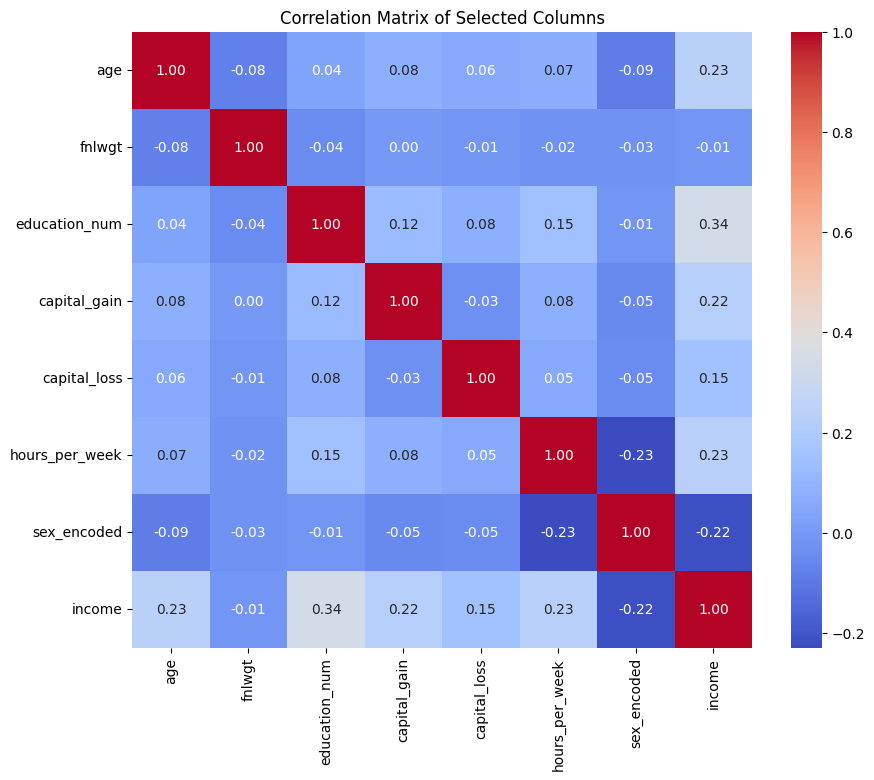

In [21]:
# Select specific columns for correlation analysis
train_data['sex_encoded'], _ = pd.factorize(train_data['sex'])

cols_to_correlate = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'sex_encoded', 'income']
subset_data = train_data[cols_to_correlate]

# Calculate the correlation matrix
corr_matrix = subset_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Selected Columns')
plt.show()


### Proportion of Income Classes Across Education Levels

We analyze the distribution of income classes across different education levels:

1. **Grouping Data**: Group by `education` and `income`, then calculate the size of each group.

2. **Calculating Proportions**: Convert counts to proportions within each education level.

3. **Preparing Data for Plotting**:
   - Reset index for plotting.
   - Melt the DataFrame for easier plotting with seaborn.
   - Map income values to readable labels (`<=50K`, `>50K`).

4. **Plotting Proportions**:
   - Use a bar plot to show proportions of income classes across education levels.
   - Add labels, title, and rotate x-axis labels for clarity.
   - Include a legend to distinguish income classes.

This plot reveals how the proportion of people earning `>50K` increases with higher education levels.


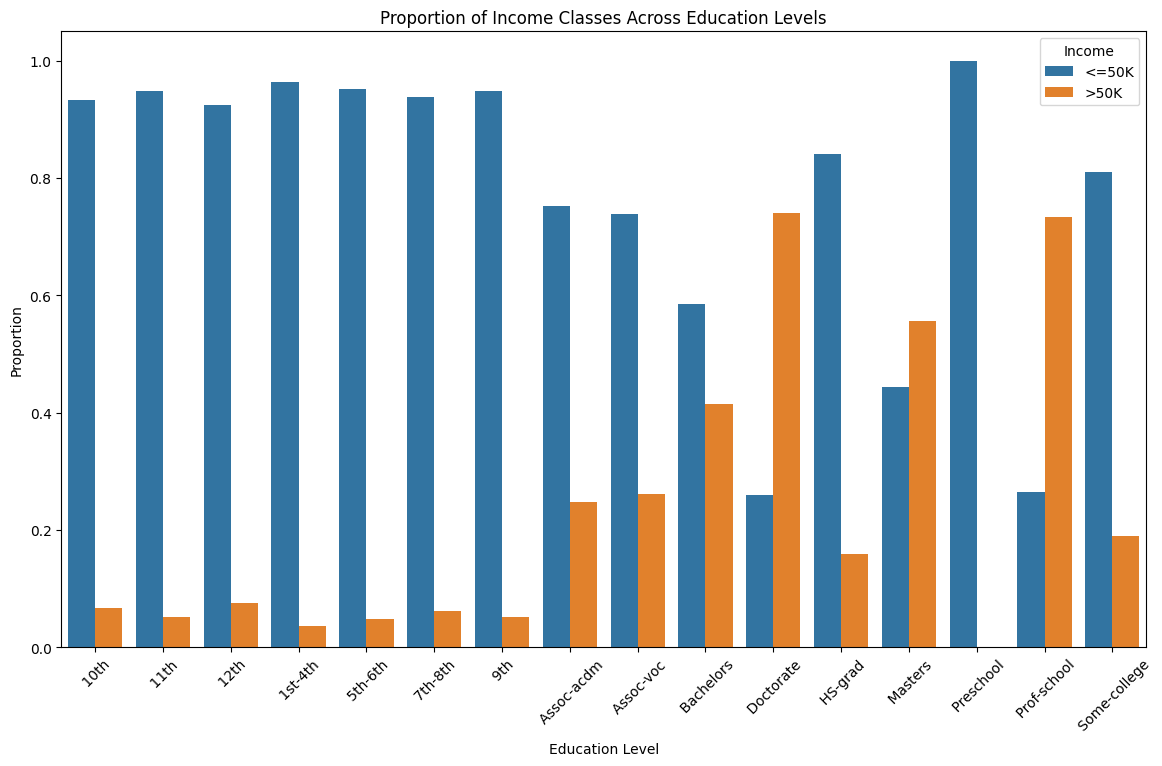

In [22]:
# Group by education and income and calculate the size
grouped = train_data.groupby(['education', 'income']).size().unstack().fillna(0)

# Calculate the proportion
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Reset index for plotting
proportions = proportions.reset_index()

# Melt the proportions DataFrame for easier plotting with seaborn
proportions_melted = proportions.melt(id_vars='education', value_vars=[0, 1], var_name='Income', value_name='Proportion')

# Map income values to labels
proportions_melted['Income'] = proportions_melted['Income'].map({0: '<=50K', 1: '>50K'})

# Plot the proportions
plt.figure(figsize=(14, 8))
sns.barplot(data=proportions_melted, x='education', y='Proportion', hue='Income')

# Add labels and title
plt.xlabel('Education Level')
plt.ylabel('Proportion')
plt.title('Proportion of Income Classes Across Education Levels')
plt.xticks(rotation=45)
plt.legend(title='Income')

# Show plot
plt.show()

<Figure size 1400x800 with 0 Axes>

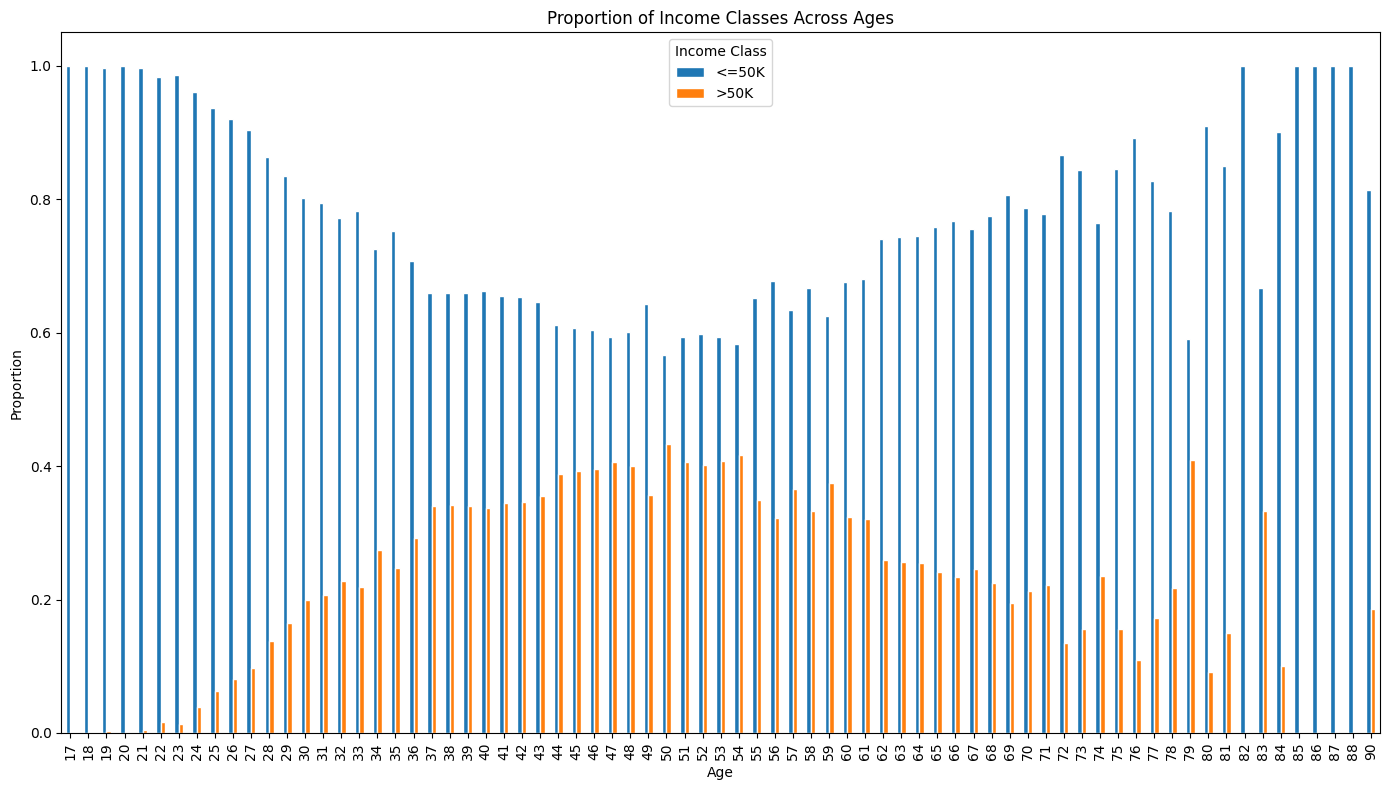

In [23]:
# Calculate the proportion of income classes for each age
income_by_age = train_data.groupby('age')['income'].value_counts(normalize=True).unstack().fillna(0)

# Rename columns for better understanding
income_by_age.columns = ['<=50K', '>50K']

# Plot the proportion of income classes across ages
plt.figure(figsize=(14, 8))
income_by_age.plot(kind='bar', edgecolor='w', figsize=(14, 8))

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Proportion')
plt.title('Proportion of Income Classes Across Ages')
plt.legend(title='Income Class')
plt.xticks(rotation=90)
plt.tight_layout()

# Show the plot
plt.show()

<Figure size 1400x800 with 0 Axes>

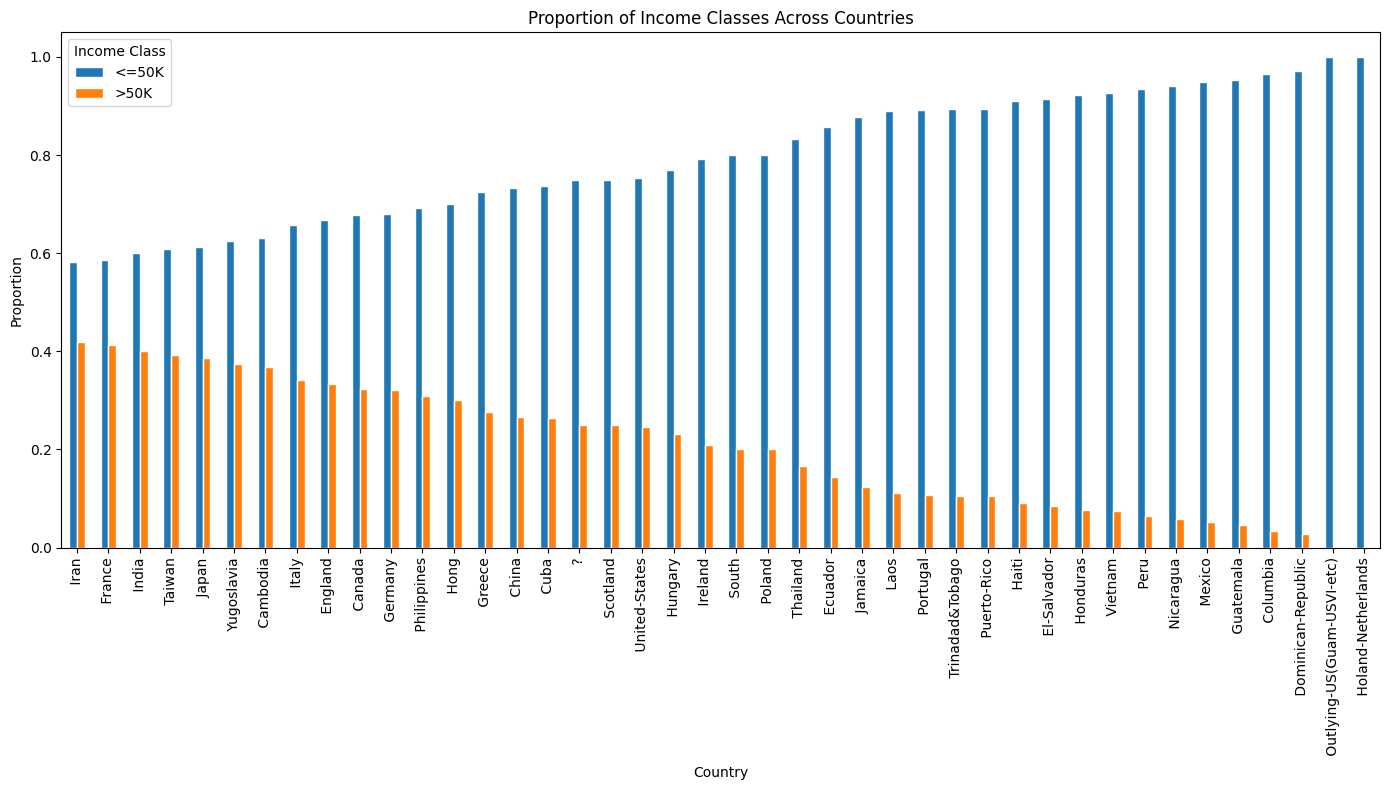

In [24]:
# Calculate the proportion of income classes for each country
income_by_country = train_data.groupby('native_country')['income'].value_counts(normalize=True).unstack().fillna(0)

# Rename columns for better understanding
income_by_country.columns = ['<=50K', '>50K']

# Sort by the proportion of >50K for better visualization
income_by_country = income_by_country.sort_values(by='>50K', ascending=False)

# Plot the proportion of income classes across countries
plt.figure(figsize=(14, 8))
income_by_country.plot(kind='bar', edgecolor='w', figsize=(14, 8))

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Proportion')
plt.title('Proportion of Income Classes Across Countries')
plt.legend(title='Income Class')
plt.xticks(rotation=90)
plt.tight_layout()

# Show the plot
plt.show()

## 4. Define Model Evaluation Function


In [25]:
# Encode categorical variables
categorical_cols = train_data.select_dtypes(include=['object']).columns
train_data[categorical_cols] = train_data[categorical_cols].apply(LabelEncoder().fit_transform)

# Normalize numerical features
numerical_cols = train_data.select_dtypes(include=['int64']).columns
train_data[numerical_cols] = StandardScaler().fit_transform(train_data[numerical_cols])

# Encode target variable as binary
train_data['income'] = LabelEncoder().fit_transform(train_data['income'])

In [26]:
train_data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,sex_encoded
0,0.030671,2.150579,-1.063611,-0.335437,1.134739,0.921634,-1.317809,-0.277805,0.393668,0.703071,0.148453,-0.21666,-0.035429,0.291569,0,-0.703071
1,0.837109,1.463736,-1.008707,-0.335437,1.134739,-0.406212,-0.608387,-0.900181,0.393668,0.703071,-0.145920,-0.21666,-2.222153,0.291569,0,-0.703071
2,-0.042642,0.090050,0.245079,0.181332,-0.420060,-1.734058,-0.135438,-0.277805,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.291569,0,-0.703071
3,1.057047,0.090050,0.425801,-2.402511,-1.197459,-0.406212,-0.135438,-0.900181,-1.962621,0.703071,-0.145920,-0.21666,-0.035429,0.291569,0,-0.703071
4,-0.775768,0.090050,1.408176,-0.335437,1.134739,-0.406212,0.810458,2.211698,-1.962621,-1.422331,-0.145920,-0.21666,-0.035429,-4.054223,0,1.422331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-0.849080,0.090050,0.639741,-0.852205,0.746039,-0.406212,1.519881,2.211698,0.393668,-1.422331,-0.145920,-0.21666,-0.197409,0.291569,0,1.422331
32557,0.103983,0.090050,-0.335433,0.181332,-0.420060,-0.406212,0.101036,-0.900181,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.291569,1,-0.703071
32558,1.423610,0.090050,-0.358777,0.181332,-0.420060,2.249480,-1.317809,1.589322,0.393668,-1.422331,-0.145920,-0.21666,-0.035429,0.291569,0,1.422331
32559,-1.215643,0.090050,0.110960,0.181332,-0.420060,0.921634,-1.317809,0.966947,0.393668,0.703071,-0.145920,-0.21666,-1.655225,0.291569,0,-0.703071


In [27]:
# Encode categorical variables
train_data_dummies = pd.get_dummies(train_data, columns=train_data.columns)


### Define Model Evaluation Function
This cell defines the `model_eval` function to compute various performance metrics for the machine learning models. It calculates accuracy, precision, recall, F1 score, sensitivity, specificity, and error rate using the confusion matrix.

In [28]:
def model_eval(actual, pred):
    # Create confusion matrix
    confusion = pd.crosstab(actual, pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

    # Extract values from the confusion matrix
    TP = confusion.loc[1, 1]
    TN = confusion.loc[0, 0]
    FP = confusion.loc[0, 1]
    FN = confusion.loc[1, 0]

    # Calculate evaluation metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f_measure = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    sensitivity = recall
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    error_rate = 1 - accuracy

    # Create output dictionary
    out = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f_measure': f_measure,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'error_rate': error_rate
    }

    return out

In [29]:
# Split data
X = train_data.drop('income', axis=1)
y = train_data['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
X_test

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,sex_encoded
14160,-0.849080,0.090050,-0.280444,1.214869,-0.031360,-1.734058,-1.317809,-0.277805,0.393668,-1.422331,-0.145920,-0.21666,-0.197409,0.291569,1.422331
27048,0.470546,2.150579,-1.318934,0.181332,-0.420060,-0.406212,-0.608387,2.211698,0.393668,-1.422331,-0.145920,-0.21666,-0.035429,0.291569,1.422331
28868,-0.702455,0.090050,-0.036669,-0.335437,1.134739,-0.406212,-0.608387,-0.900181,-1.962621,0.703071,-0.145920,-0.21666,1.179417,0.291569,-0.703071
5667,-0.629143,0.090050,0.002479,-0.335437,1.134739,0.921634,0.101036,-0.277805,0.393668,-1.422331,-0.145920,-0.21666,-0.035429,0.291569,1.422331
7827,-0.702455,1.463736,-0.004096,1.214869,-0.031360,-1.734058,-0.844861,-0.277805,0.393668,0.703071,0.152244,-0.21666,0.774468,0.291569,-0.703071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32476,-0.262580,0.090050,-1.507417,-2.144127,-0.808759,-0.406212,-0.844861,-0.900181,0.393668,0.703071,-0.145920,-0.21666,3.528120,0.291569,-0.703071
21100,-1.069018,0.090050,-1.305614,-0.335437,1.134739,0.921634,0.810458,0.966947,0.393668,-1.422331,-0.145920,-0.21666,-1.655225,0.291569,1.422331
27131,-1.069018,0.090050,2.392227,0.181332,-0.420060,0.921634,-0.608387,0.966947,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.291569,-0.703071
25526,1.276984,0.090050,-0.108248,1.214869,-0.031360,-0.406212,0.810458,-0.900181,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.291569,-0.703071


In [31]:
X_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,sex_encoded
19749,-0.335892,1.463736,-1.263102,0.181332,-0.420060,-0.406212,-0.371912,2.211698,0.393668,-1.422331,-0.145920,5.190905,-2.303143,0.291569,1.422331
1216,0.690484,1.463736,0.510218,1.214869,-0.031360,-0.406212,-0.844861,-0.900181,-4.318909,0.703071,0.895083,-0.216660,-0.035429,0.291569,-0.703071
27962,-1.142331,2.150579,-1.263652,1.214869,-0.031360,-0.406212,0.810458,-0.900181,0.393668,0.703071,-0.145920,-0.216660,-0.845327,0.291569,-0.703071
23077,1.276984,-1.283635,0.621778,0.181332,-0.420060,-1.734058,-0.608387,-0.277805,0.393668,-1.422331,-0.145920,-0.216660,-0.035429,0.291569,1.422331
10180,-1.582206,0.090050,1.018184,-2.402511,-1.197459,0.921634,0.573984,0.966947,0.393668,-1.422331,-0.145920,-0.216660,-2.546112,0.291569,1.422331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,0.617171,0.090050,1.607629,-0.335437,1.134739,-0.406212,-0.844861,-0.900181,0.393668,0.703071,-0.145920,-0.216660,-0.035429,0.291569,-0.703071
5390,-0.555830,0.090050,-0.403259,-2.144127,-0.808759,-1.734058,0.337510,1.589322,0.393668,-1.422331,-0.145920,-0.216660,-1.574235,0.291569,1.422331
860,-1.508894,0.090050,0.251123,-2.402511,-1.197459,0.921634,-1.317809,0.966947,0.393668,-1.422331,-0.145920,-0.216660,-1.655225,0.291569,1.422331
15795,0.837109,1.463736,-1.283936,0.181332,-0.420060,-0.406212,-0.371912,-0.900181,0.393668,0.703071,-0.145920,-0.216660,3.528120,0.291569,-0.703071


In [32]:


# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Neural Network': MLPClassifier(max_iter=1000)
}
results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    # Evaluate the model
    metrics = model_eval(y_test, pred)
    accuracy = metrics['accuracy']
    f1 = f1_score(y_test, pred, average='weighted')

    # Append results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F Measure': metrics['f_measure'],
        'Sensitivity': metrics['sensitivity'],
        'Specificity': metrics['specificity'],
        'Error Rate': metrics['error_rate']
    })


# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results)


### Model Performance Comparison

In comparing the performance of various models, several metrics were considered: accuracy, F1 score, precision, recall, F measure, sensitivity, specificity, and error rate. Here are the key takeaways:

1. **Accuracy**:
   - The highest accuracy was achieved by Gradient Boosting (87.00%), followed by AdaBoost (86.50%) and SVM (85.94%).
   - Decision Tree had the lowest accuracy at 81.52%.

2. **F1 Score**:
   - Gradient Boosting also led in F1 Score (86.38%), with AdaBoost close behind (86.01%).
   - Decision Tree had the lowest F1 Score (81.65%).

3. **Precision**:
   - Gradient Boosting showed the highest precision (79.23%), indicating a lower false positive rate.
   - Decision Tree had the lowest precision (60.55%).

4. **Recall**:
   - AdaBoost had the highest recall (62.49%), indicating it was best at identifying true positives.
   - SVM had the lowest recall (59.03%).

5. **F Measure**:
   - Gradient Boosting had the highest F Measure (69.02%), balancing precision and recall effectively.
   - Decision Tree had the lowest F Measure (61.82%).

6. **Sensitivity**:
   - AdaBoost led in sensitivity (62.49%), indicating better performance on true positives.
   - SVM had the lowest sensitivity (59.03%).

7. **Specificity**:
   - Gradient Boosting had the highest specificity (95.02%), showing it was effective at identifying true negatives.
   - Decision Tree had the lowest specificity (87.23%).

8. **Error Rate**:
   - Gradient Boosting had the lowest error rate (13.00%), making it the most reliable model.
   - Decision Tree had the highest error rate (18.48%).

**Summary**: Gradient Boosting consistently outperformed other models across most metrics, making it the top choice for this dataset. AdaBoost and SVM also performed well but fell slightly behind in precision and recall. Decision Tree, while straightforward, lagged in overall performance metrics.


In [33]:
results_df

,Model,Accuracy,F1 Score,Precision,Recall,F Measure,Sensitivity,Specificity,Error Rate
0,Logistic Regression,0.825878,0.811375,0.706955,0.452463,0.551779,0.452463,0.941784,0.174122
1,Decision Tree,0.810728,0.811892,0.596915,0.618842,0.607681,0.618842,0.870288,0.189272
2,Random Forest,0.855461,0.851124,0.730337,0.617978,0.669476,0.617978,0.929175,0.144539
3,SVM,0.850650,0.841722,0.755529,0.546240,0.634061,0.546240,0.945137,0.149350
4,KNN,0.828949,0.825581,0.655239,0.586430,0.618928,0.586430,0.904225,0.171051
5,AdaBoost,0.863650,0.858442,0.762006,0.617113,0.681948,0.617113,0.940174,0.136350
6,Gradient Boosting,0.867643,0.861086,0.789235,0.601988,0.683011,0.601988,0.950101,0.132357
7,Neural Network,0.850957,0.845796,0.724607,0.598099,0.655303,0.598099,0.929443,0.149043


### Model Metric Comparison Plots

We visualize the performance of different models across various metrics:

1. **Function Definition**: `plot_metric_bar` creates bar charts for a given metric from the `results_df` DataFrame.
   - The bar chart compares model performance for the specified metric.
   - Customizable y-axis limits ensure all metrics fit within the same scale.

2. **Plotting Metrics**: For each metric (Accuracy, F1 Score, Precision, Recall, F Measure, Sensitivity, Specificity, Error Rate), a bar chart is generated.
   - This helps in visual comparison of model performance across all key metrics.

These plots provide a clear, visual representation of how each model performs, aiding in the selection of the best model based on various criteria.


<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


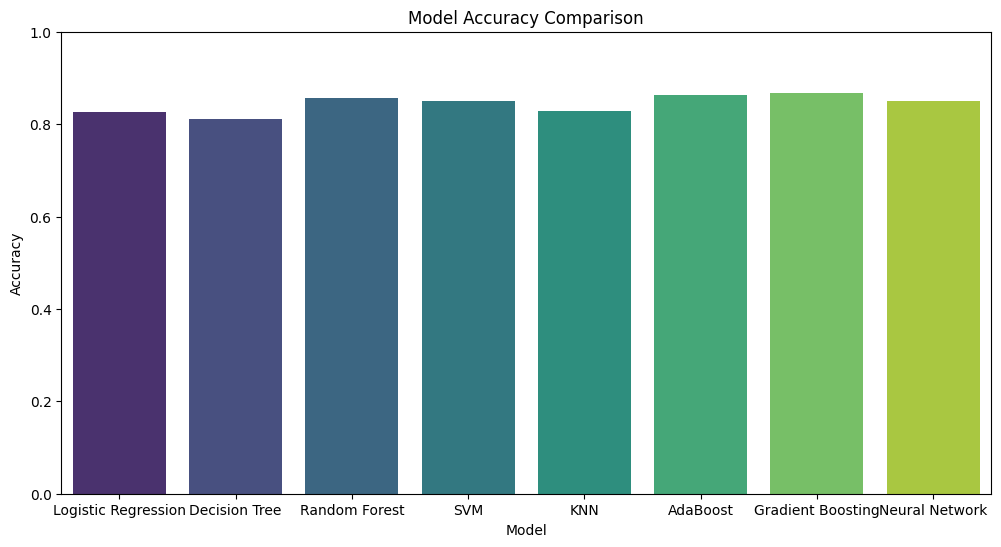

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


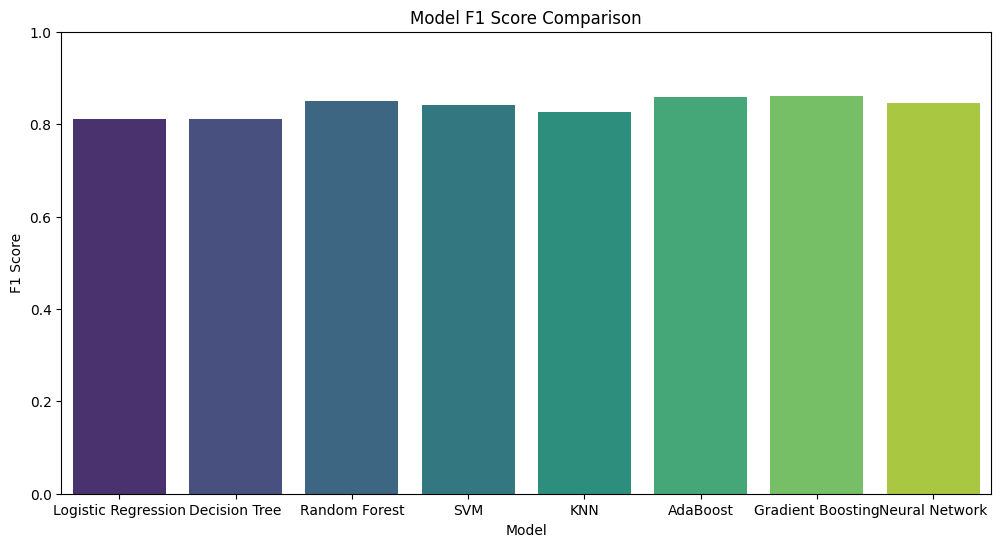

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


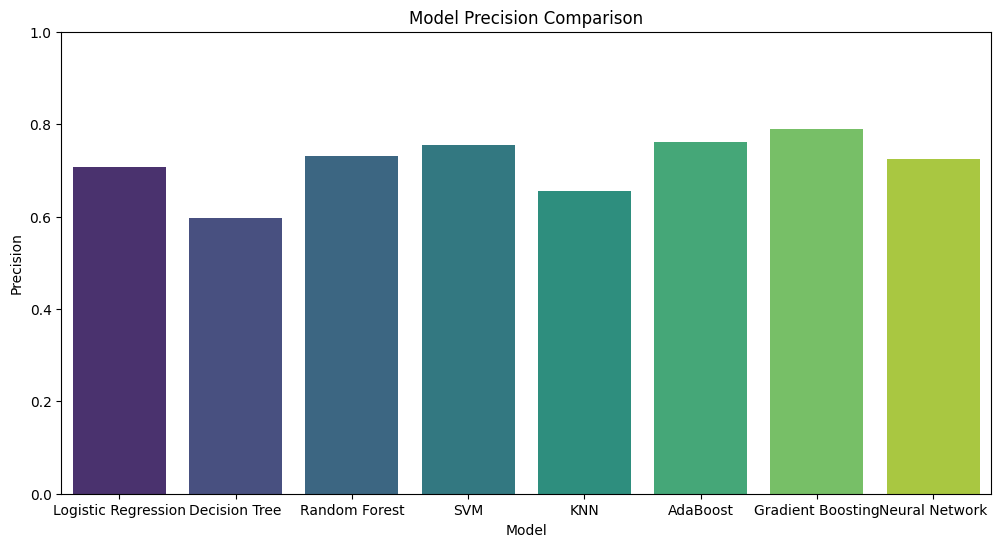

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


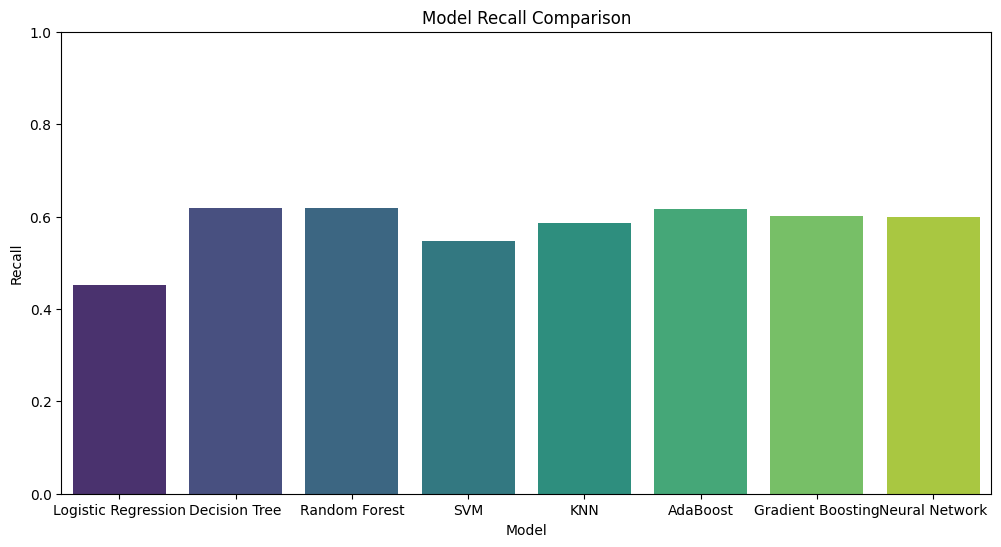

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


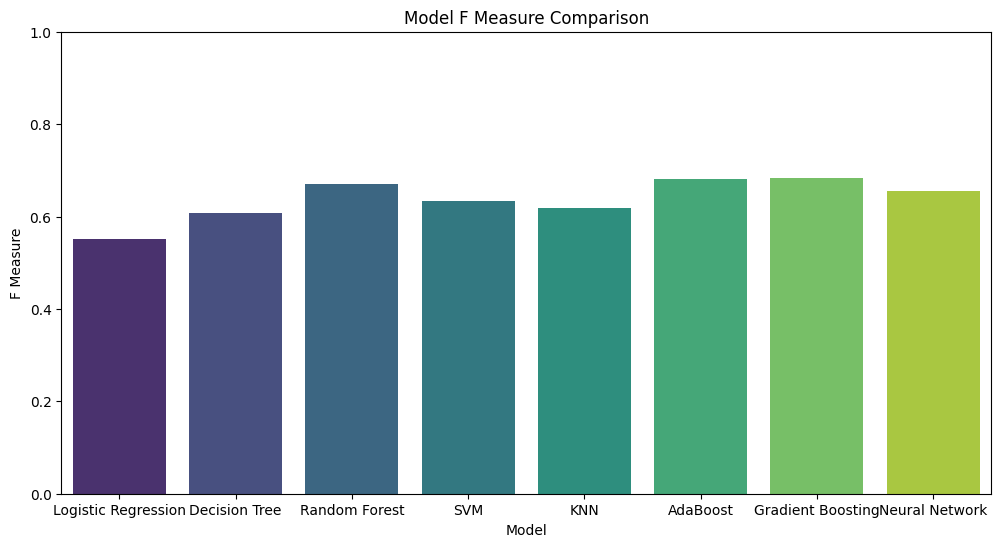

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


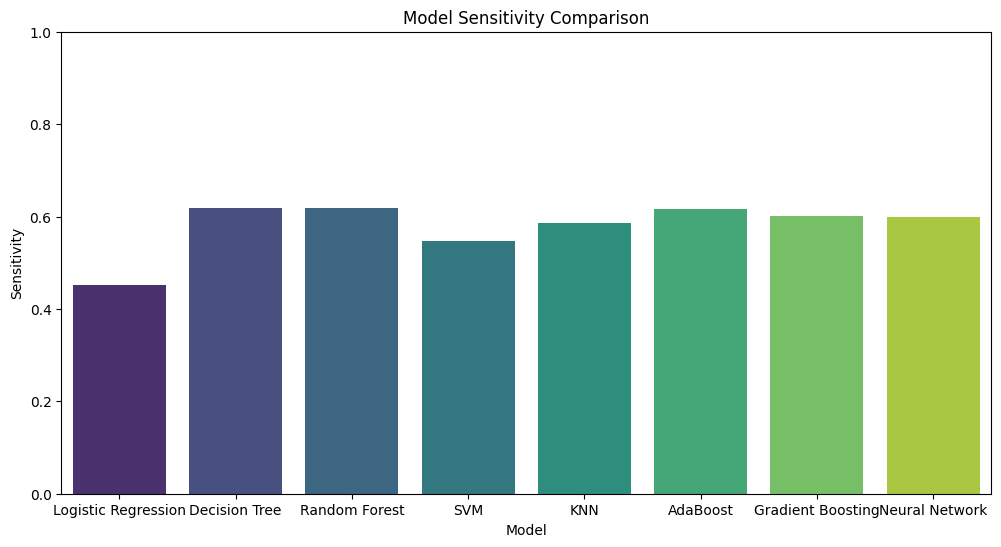

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


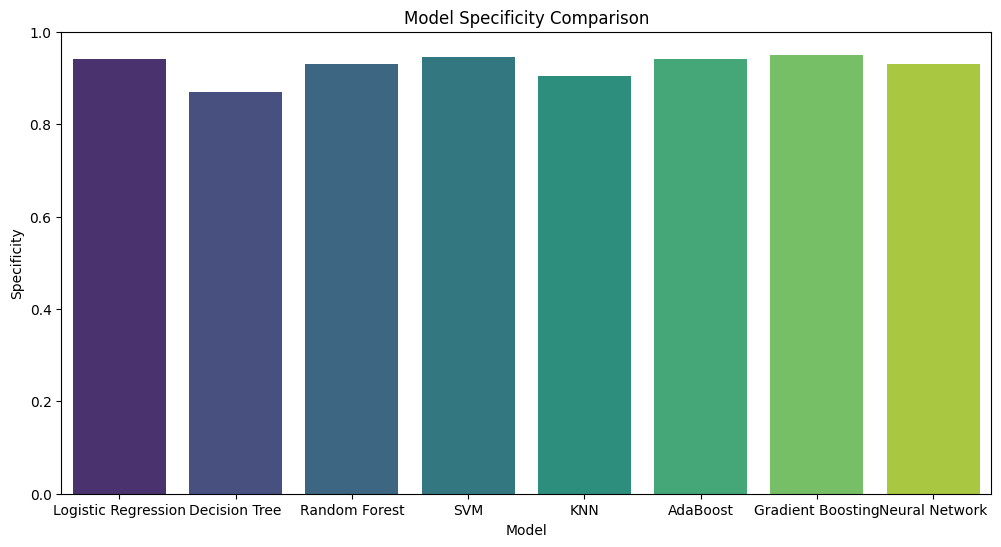

<ipython-input-34-d06203a23155>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')


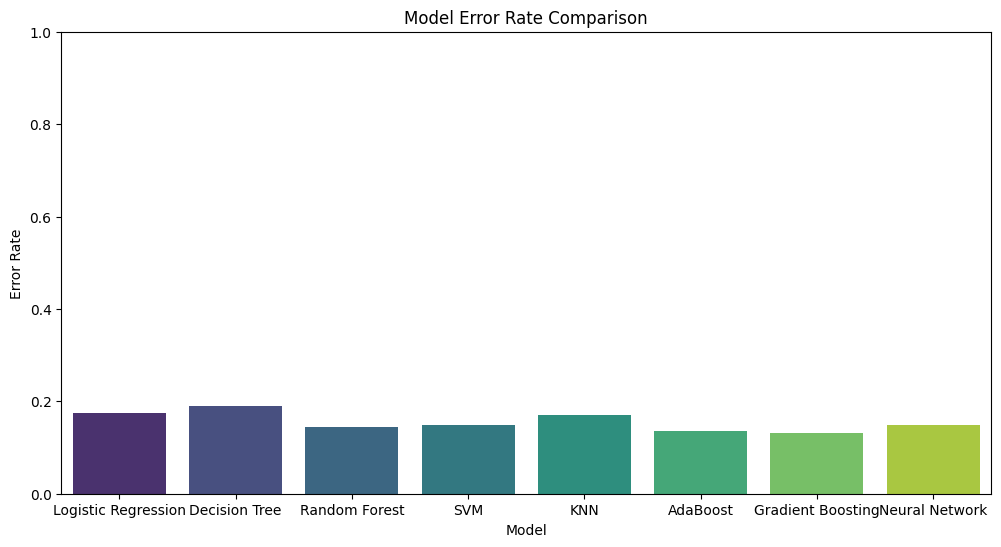

In [34]:
# Function to plot bar charts for a specific metric
def plot_metric_bar(results_df, metric, ylim=(0, 1)):
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
    plt.title(f'Model {metric} Comparison')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.ylim(ylim)
    plt.show()


# Assuming results_df is already created and contains all necessary metrics
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'F Measure', 'Sensitivity', 'Specificity', 'Error Rate']

# Plot each metric
for metric in metrics:
    plot_metric_bar(results_df, metric)



In [35]:

def demographic_parity_difference(y_true, y_pred, sensitive_features):
    metric = MetricFrame(metrics=accuracy_score, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    return metric.difference()

In [ ]:
print("\nFairness Metrics:")
sensitive_feature = X_test['race']
for name, model in models.items():
    predictions = model.predict(X_test)
    dem_parity_diff = demographic_parity_difference(y_test, predictions, sensitive_features=sensitive_feature)
    print(f'{name} - Demographic Parity Difference: {dem_parity_diff:.4f}')


Fairness Metrics:
Logistic Regression - Demographic Parity Difference: 0.1326
Decision Tree - Demographic Parity Difference: 0.1351
Random Forest - Demographic Parity Difference: 0.1040
SVM - Demographic Parity Difference: 0.1196
KNN - Demographic Parity Difference: 0.1030
AdaBoost - Demographic Parity Difference: 0.1013
Gradient Boosting - Demographic Parity Difference: 0.0728
Neural Network - Demographic Parity Difference: 0.0984


In [40]:
X_test.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'sex_encoded'],
      dtype='object')

In [42]:
from fairlearn.metrics import demographic_parity_difference

# List of sensitive features
sensitive_features_list = ['race', 'education', 'sex']

print("\nFairness Metrics:")
for sensitive_feature in sensitive_features_list:
    print(f"\nEvaluating fairness for sensitive feature: {sensitive_feature}")
    for name, model in models.items():
        predictions = model.predict(X_test)
        dem_parity_diff = demographic_parity_difference(y_test, predictions, sensitive_features=X_test[sensitive_feature])
        print(f'{name} - Demographic Parity Difference for {sensitive_feature}: {dem_parity_diff:.4f}')



Fairness Metrics:

Evaluating fairness for sensitive feature: race
Logistic Regression - Demographic Parity Difference for race: 0.1131
Decision Tree - Demographic Parity Difference for race: 0.1340
Random Forest - Demographic Parity Difference for race: 0.1749
SVM - Demographic Parity Difference for race: 0.1831
KNN - Demographic Parity Difference for race: 0.2166
AdaBoost - Demographic Parity Difference for race: 0.2091
Gradient Boosting - Demographic Parity Difference for race: 0.2057
Neural Network - Demographic Parity Difference for race: 0.2013

Evaluating fairness for sensitive feature: education
Logistic Regression - Demographic Parity Difference for education: 0.8402
Decision Tree - Demographic Parity Difference for education: 0.7442
Random Forest - Demographic Parity Difference for education: 0.8284
SVM - Demographic Parity Difference for education: 0.7863
KNN - Demographic Parity Difference for education: 0.7811
AdaBoost - Demographic Parity Difference for education: 0.7436

## Evaluating Fairness for Sensitive Feature: Race
Logistic Regression: 0.1131
Decision Tree: 0.1340
Random Forest: 0.1749
SVM: 0.1831
KNN: 0.2166
AdaBoost: 0.2091
Gradient Boosting: 0.2057
Neural Network: 0.2013
Analysis:

### Logistic Regression shows the lowest demographic parity difference for race, indicating it is the fairest model among those tested concerning racial fairness.

### KNN and AdaBoost display higher demographic parity differences, indicating more significant disparities in predictions between racial groups.

## Evaluating Fairness for Sensitive Feature: Education
Logistic Regression: 0.8402
Decision Tree: 0.7442
Random Forest: 0.8284
SVM: 0.7863
KNN: 0.7811
AdaBoost: 0.7436
Gradient Boosting: 0.7949
Neural Network: 0.8120
Analysis:

### AdaBoost and Decision Tree exhibit the lowest demographic parity differences for education, suggesting relatively better fairness concerning educational groups.
### Logistic Regression and Random Forest have the highest differences, indicating the most significant educational group disparities in their predictions.

## Evaluating Fairness for Sensitive Feature: Sex
Logistic Regression: 0.1755
Decision Tree: 0.1904
Random Forest: 0.1778
SVM: 0.1638
KNN: 0.1915
AdaBoost: 0.1872
Gradient Boosting: 0.1645
Neural Network: 0.1830
Analysis:

### SVM and Gradient Boosting have the lowest demographic parity differences for sex, indicating they are the fairest models with respect to gender fairness.
### KNN and Decision Tree show higher differences, suggesting more significant gender disparities in their predictions.

## Summary
Race: Logistic Regression is the fairest, while KNN and AdaBoost show more bias.
Education: AdaBoost and Decision Tree are the fairest, while Logistic Regression and Random Forest are more biased.
Sex: SVM and Gradient Boosting are the fairest, while KNN and Decision Tree exhibit more bias.
These results illustrate that no single model is uniformly fair across all sensitive features. Fairness in machine learning often requires a careful selection and evaluation of models based on the specific context and the most critical fairness criteria for the application. The results also underscore the importance of evaluating multiple models and fairness metrics to ensure equitable treatment across different demographic groups.